# Distribución Conjunta Discreta

Sean $X$ e $Y$ dos variables aleatorias discretas.

La **función de probabilidad conjunta** se define como:

$$
p_{X,Y}(x,y) = P(X = x, Y = y)
$$

Debe cumplir:

$$
p_{X,Y}(x,y) \ge 0
$$

y la condición de normalización:

$$
\sum_x \sum_y p_{X,Y}(x,y) = 1
$$

---

## Interpretación Geométrica

- Es una tabla de probabilidades.
- También puede verse como una superficie en $\mathbb{R}^3$.
- El eje vertical representa la probabilidad.

Cada punto $(x,y)$ tiene una "altura" igual a $p_{X,Y}(x,y)$.

La suma total de todas las probabilidades debe ser 1.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from ipywidgets import interact

plt.style.use("seaborn-v0_8")


In [6]:
# Valores posibles
x_vals = np.array([0, 1, 2])
y_vals = np.array([0, 1, 2])

# Tabla de probabilidades (ejemplo con dependencia leve)
P = np.array([
    [0.05, 0.10, 0.05],
    [0.10, 0.30, 0.10],
    [0.05, 0.10, 0.15]
])

print("Suma total:", P.sum())
P


Suma total: 1.0


array([[0.05, 0.1 , 0.05],
       [0.1 , 0.3 , 0.1 ],
       [0.05, 0.1 , 0.15]])

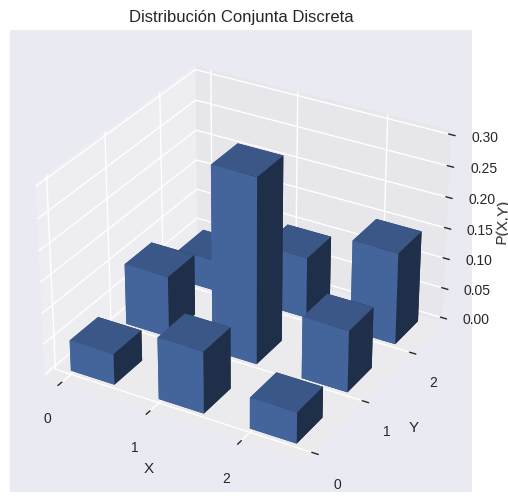

In [7]:
def plot_joint(P):
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    xpos, ypos = np.meshgrid(x_vals, y_vals, indexing="ij")
    xpos = xpos.flatten()
    ypos = ypos.flatten()
    zpos = np.zeros_like(xpos)

    dx = dy = 0.5
    dz = P.flatten()

    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('P(X,Y)')
    ax.set_title('Distribución Conjunta Discreta')

    ax.set_xticks(x_vals)
    ax.set_yticks(y_vals)

    plt.show()

plot_joint(P)


## Interpretación

Cada barra representa:

$$
P(X = x, Y = y)
$$

Observaciones importantes:

- La altura representa probabilidad.
- La suma de todas las barras es 1.
- Si la masa se concentra en la diagonal, sugiere dependencia positiva.
- Si todas las barras son iguales, sugiere independencia uniforme.


In [8]:
def generate_distribution(alpha):
    base = np.ones((3,3))

    # Agregamos peso a la diagonal
    for i in range(3):
        base[i,i] += alpha

    P = base / base.sum()
    return P

def interactive_plot(alpha=0):
    P = generate_distribution(alpha)
    plot_joint(P)
    print("Suma total:", P.sum())

interact(interactive_plot,
         alpha=widgets.FloatSlider(min=0, max=5, step=0.5, value=0));


interactive(children=(FloatSlider(value=0.0, description='alpha', max=5.0, step=0.5), Output()), _dom_classes=…

## Dependencia Intuitiva

Cuando aumentamos $\alpha$:

- Aumenta la probabilidad de que $X = Y$.
- La distribución deja de ser uniforme.
- Se empieza a generar estructura.

Todavía no definimos independencia formalmente,
pero ya podemos **verla geométricamente**.


# Distribuciones Marginales Discretas

Dada una distribución conjunta:

$$
p_{X,Y}(x,y)
$$

podemos obtener las distribuciones marginales sumando sobre la otra variable.

---

## Marginal de $X$

$$
p_X(x) = \sum_y p_{X,Y}(x,y)
$$

---

## Marginal de $Y$

$$
p_Y(y) = \sum_x p_{X,Y}(x,y)
$$

---

## Interpretación Geométrica

Marginalizar significa:

- "Colapsar" la dimensión verticalmente.
- Sumar todas las alturas en una dirección.
- Proyectar la superficie 3D sobre un eje.

Es equivalente a sumar filas o columnas en la tabla.


In [9]:
def compute_marginals(P):
    p_X = P.sum(axis=1)  # suma sobre columnas
    p_Y = P.sum(axis=0)  # suma sobre filas
    return p_X, p_Y

p_X, p_Y = compute_marginals(P)

print("Marginal de X:", p_X)
print("Suma p_X:", p_X.sum())

print("\nMarginal de Y:", p_Y)
print("Suma p_Y:", p_Y.sum())


Marginal de X: [0.2 0.5 0.3]
Suma p_X: 1.0

Marginal de Y: [0.2 0.5 0.3]
Suma p_Y: 1.0


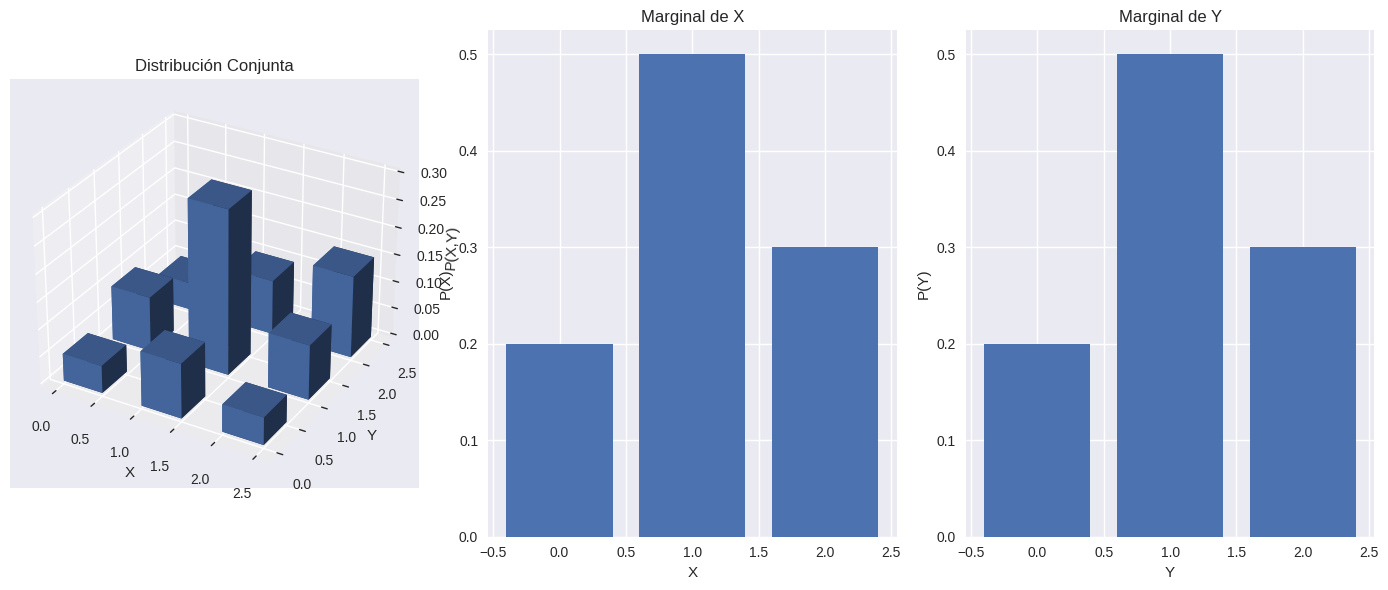

In [10]:
def plot_joint_with_marginals(P):
    p_X, p_Y = compute_marginals(P)

    fig = plt.figure(figsize=(14,6))

    # --- Distribución conjunta ---
    ax1 = fig.add_subplot(131, projection='3d')

    xpos, ypos = np.meshgrid(x_vals, y_vals, indexing="ij")
    xpos = xpos.flatten()
    ypos = ypos.flatten()
    zpos = np.zeros_like(xpos)

    dx = dy = 0.5
    dz = P.flatten()

    ax1.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)
    ax1.set_title("Distribución Conjunta")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("P(X,Y)")

    # --- Marginal X ---
    ax2 = fig.add_subplot(132)
    ax2.bar(x_vals, p_X)
    ax2.set_title("Marginal de X")
    ax2.set_xlabel("X")
    ax2.set_ylabel("P(X)")

    # --- Marginal Y ---
    ax3 = fig.add_subplot(133)
    ax3.bar(y_vals, p_Y)
    ax3.set_title("Marginal de Y")
    ax3.set_xlabel("Y")
    ax3.set_ylabel("P(Y)")

    plt.tight_layout()
    plt.show()

plot_joint_with_marginals(P)


## Qué está pasando aquí

Cuando calculamos:

$$
p_X(x) = \sum_y p_{X,Y}(x,y)
$$

estamos sumando todas las probabilidades asociadas a un valor fijo de $x$.

Geométricamente:

- Sumamos todas las barras alineadas en la dirección $y$.
- Obtenemos una sola barra en el eje $X$.

Lo mismo ocurre para $p_Y(y)$.

---

## Propiedad Fundamental

Las marginales también son distribuciones válidas:

$$
\sum_x p_X(x) = 1
$$

$$
\sum_y p_Y(y) = 1
$$


In [11]:
def interactive_marginals(alpha=0):
    P = generate_distribution(alpha)
    plot_joint_with_marginals(P)
    print("Suma total conjunta:", P.sum())

interact(interactive_marginals,
         alpha=widgets.FloatSlider(min=0, max=5, step=0.5, value=0));


interactive(children=(FloatSlider(value=0.0, description='alpha', max=5.0, step=0.5), Output()), _dom_classes=…

# Nueva Construcción Paramétrica

Construiremos una distribución conjunta como combinación de:

- Un componente independiente
- Un componente dependiente (diagonal)

Modelo:

$$
P = (1 - \lambda) P_{\text{indep}} + \lambda P_{\text{dep}}
$$

donde:

- $0 \le \lambda \le 1$
- $P_{\text{indep}} = p_X p_Y^T$
- $P_{\text{dep}}$ concentra masa en la diagonal

Además permitiremos modificar las marginales base.


In [12]:
def generate_distribution(lambda_dep=0.0, skew_x=0.0, skew_y=0.0):

    # Marginal base para X
    p_X = np.array([1, 1 + skew_x, 1 + 2*skew_x])
    p_X = p_X / p_X.sum()

    # Marginal base para Y
    p_Y = np.array([1, 1 + skew_y, 1 + 2*skew_y])
    p_Y = p_Y / p_Y.sum()

    # Parte independiente
    P_indep = np.outer(p_X, p_Y)

    # Parte dependiente (diagonal fuerte)
    P_dep = np.zeros((3,3))
    for i in range(3):
        P_dep[i,i] = p_X[i]  # masa en diagonal
    P_dep = P_dep / P_dep.sum()

    # Mezcla convexa
    P = (1 - lambda_dep) * P_indep + lambda_dep * P_dep

    return P


In [13]:
def interactive_marginals(lambda_dep=0.0, skew_x=0.0, skew_y=0.0):

    P = generate_distribution(lambda_dep, skew_x, skew_y)

    plot_joint_with_marginals(P)

    print("Suma total conjunta:", P.sum())

interact(
    interactive_marginals,
    lambda_dep=widgets.FloatSlider(min=0, max=1, step=0.1, value=0),
    skew_x=widgets.FloatSlider(min=0, max=2, step=0.2, value=0),
    skew_y=widgets.FloatSlider(min=0, max=2, step=0.2, value=0)
);


interactive(children=(FloatSlider(value=0.0, description='lambda_dep', max=1.0), FloatSlider(value=0.0, descri…

# Distribuciones Condicionales Discretas

Dada una distribución conjunta:

$$
p_{X,Y}(x,y)
$$

definimos la distribución condicional de $X$ dado $Y=y$ como:

$$
p_{X|Y}(x|y) = \frac{p_{X,Y}(x,y)}{p_Y(y)}
$$

siempre que:

$$
p_Y(y) > 0
$$

---

## Interpretación

Fijar $Y = y$ significa:

- Tomar una "columna" de la tabla conjunta.
- Reescalar sus valores para que sumen 1.

Es decir:

- La condicional es una distribución válida.
- Cambia cuando cambiamos el valor de $y$.
- Si cambia con $y$, existe dependencia.
- Si no cambia con $y$, hay independencia.


In [14]:
def compute_conditionals(P):

    p_X, p_Y = compute_marginals(P)

    cond_X_given_Y = np.zeros_like(P)

    for j in range(len(p_Y)):
        if p_Y[j] > 0:
            cond_X_given_Y[:, j] = P[:, j] / p_Y[j]

    return cond_X_given_Y


In [15]:
def plot_conditional(P, y_index):

    cond = compute_conditionals(P)
    p_X_given_y = cond[:, y_index]

    fig, ax = plt.subplots(figsize=(6,4))

    ax.bar(x_vals, p_X_given_y)
    ax.set_title(f"Distribución Condicional P(X | Y={y_vals[y_index]})")
    ax.set_xlabel("X")
    ax.set_ylabel("Probabilidad")

    ax.set_ylim(0, 1)

    plt.show()

    print("Suma:", p_X_given_y.sum())


In [16]:
def interactive_conditionals(lambda_dep=0.0, skew_x=0.0, skew_y=0.0, y_index=0):

    P = generate_distribution(lambda_dep, skew_x, skew_y)

    print("Distribución conjunta:")
    plot_joint(P)

    print("\nDistribución condicional:")
    plot_conditional(P, y_index)

interact(
    interactive_conditionals,
    lambda_dep=widgets.FloatSlider(min=0, max=1, step=0.1, value=0),
    skew_x=widgets.FloatSlider(min=0, max=2, step=0.2, value=0),
    skew_y=widgets.FloatSlider(min=0, max=2, step=0.2, value=0),
    y_index=widgets.IntSlider(min=0, max=2, step=1, value=0)
);


interactive(children=(FloatSlider(value=0.0, description='lambda_dep', max=1.0), FloatSlider(value=0.0, descri…

# Observación Fundamental

Si $X$ e $Y$ son independientes, entonces:

$$
p_{X|Y}(x|y) = p_X(x)
$$

para todo $y$.

Es decir:

- La distribución condicional NO cambia cuando cambiamos $y$.
- Saber $Y$ no aporta información sobre $X$.

Si la condicional cambia al variar $y$:

- Existe dependencia.
- Conocer $Y$ modifica nuestras probabilidades sobre $X$.

---

## Intuición Clave

Independencia significa:

> La información sobre una variable no altera la distribución de la otra.


# Independencia Discreta

Decimos que $X$ e $Y$ son independientes si:

$$
p_{X,Y}(x,y) = p_X(x) \, p_Y(y)
$$

para todo $x,y$.

---

## Interpretación

La distribución conjunta se puede factorizar como el producto de sus marginales.

Equivalente a decir:

$$
p_{X|Y}(x|y) = p_X(x)
$$

para todo $y$.

---

## Idea Geométrica

Independencia significa que:

- La superficie conjunta no tiene "estructura inclinada".
- No hay patrón diagonal.
- Es simplemente el producto externo de dos vectores.


In [17]:
def check_independence(P):

    p_X, p_Y = compute_marginals(P)

    P_indep = np.outer(p_X, p_Y)

    difference = P - P_indep

    error = np.abs(difference).sum()

    return P_indep, difference, error


In [18]:
def plot_difference(P):

    P_indep, diff, error = check_independence(P)

    fig, axes = plt.subplots(1,3, figsize=(15,4))

    im0 = axes[0].imshow(P, cmap="viridis")
    axes[0].set_title("P conjunta")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(P_indep, cmap="viridis")
    axes[1].set_title("Producto p_X p_Y")
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(diff, cmap="coolwarm")
    axes[2].set_title("Diferencia")
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

    print("Error total |P - p_X p_Y| =", error)


In [19]:
def interactive_independence(lambda_dep=0.0, skew_x=0.0, skew_y=0.0):

    P = generate_distribution(lambda_dep, skew_x, skew_y)

    plot_difference(P)

interact(
    interactive_independence,
    lambda_dep=widgets.FloatSlider(min=0, max=1, step=0.1, value=0),
    skew_x=widgets.FloatSlider(min=0, max=2, step=0.2, value=0),
    skew_y=widgets.FloatSlider(min=0, max=2, step=0.2, value=0)
);


interactive(children=(FloatSlider(value=0.0, description='lambda_dep', max=1.0), FloatSlider(value=0.0, descri…

# Qué Estamos Midiendo

Estamos calculando:

$$
P - p_X p_Y
$$

Si $X$ e $Y$ son independientes:

$$
P - p_X p_Y = 0
$$

es decir, la matriz diferencia es cero.

---

## Observación Experimental

- Cuando $\lambda = 0$, el error es aproximadamente 0.
- Cuando $\lambda > 0$, aparece estructura en la matriz diferencia.
- La diagonal se vuelve dominante.
- Surge dependencia.

---

## Conclusión Conceptual

Independencia no significa:

- Que las marginales sean uniformes.

Significa:

- Que la estructura conjunta sea exactamente el producto de marginales.


# Distribución Conjunta Continua

Sean $X$ e $Y$ variables aleatorias continuas.

La **densidad conjunta** se define como:

$$
f_{X,Y}(x,y)
$$

con las propiedades:

$$
f_{X,Y}(x,y) \ge 0
$$

y

$$
\int \int f_{X,Y}(x,y) \, dx \, dy = 1
$$

---

## Interpretación Geométrica

- Ya no tenemos barras.
- Tenemos una superficie suave en $\mathbb{R}^3$.
- La probabilidad es volumen bajo la superficie.

Para una región $A$:

$$
P((X,Y) \in A) = \int\int_A f_{X,Y}(x,y) \, dx \, dy
$$


In [20]:
from scipy.stats import multivariate_normal


In [21]:
def bivariate_normal_pdf(mu_x, mu_y, sigma_x, sigma_y, rho, grid_size=100):

    x = np.linspace(mu_x - 4*sigma_x, mu_x + 4*sigma_x, grid_size)
    y = np.linspace(mu_y - 4*sigma_y, mu_y + 4*sigma_y, grid_size)

    X, Y = np.meshgrid(x, y)

    mean = [mu_x, mu_y]
    cov = [[sigma_x**2, rho*sigma_x*sigma_y],
           [rho*sigma_x*sigma_y, sigma_y**2]]

    rv = multivariate_normal(mean, cov)
    Z = rv.pdf(np.dstack((X, Y)))

    return X, Y, Z


In [22]:
def plot_surface(mu_x, mu_y, sigma_x, sigma_y, rho):

    X, Y, Z = bivariate_normal_pdf(mu_x, mu_y, sigma_x, sigma_y, rho)

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, Z, cmap='viridis')

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("f(x,y)")

    ax.set_title("Densidad Normal Bivariada")

    plt.show()


In [23]:
def interactive_surface(mu_x=0, mu_y=0, sigma_x=1, sigma_y=1, rho=0):

    plot_surface(mu_x, mu_y, sigma_x, sigma_y, rho)

interact(
    interactive_surface,
    mu_x=widgets.FloatSlider(min=-3, max=3, step=0.5, value=0),
    mu_y=widgets.FloatSlider(min=-3, max=3, step=0.5, value=0),
    sigma_x=widgets.FloatSlider(min=0.5, max=3, step=0.5, value=1),
    sigma_y=widgets.FloatSlider(min=0.5, max=3, step=0.5, value=1),
    rho=widgets.FloatSlider(min=-0.9, max=0.9, step=0.1, value=0)
);


interactive(children=(FloatSlider(value=0.0, description='mu_x', max=3.0, min=-3.0, step=0.5), FloatSlider(val…

# Qué Estamos Observando

Parámetros:

- $\mu_X$, $\mu_Y$: desplazan el centro.
- $\sigma_X$, $\sigma_Y$: controlan dispersión.
- $\rho$: controla la dependencia.

---

## Caso $\rho = 0$

La superficie es simétrica.
Las curvas de nivel son circulares (si $\sigma_X = \sigma_Y$).

Indica independencia en la normal bivariada.

---

## Caso $\rho > 0$

La superficie se inclina.
Las curvas de nivel se vuelven elipses inclinadas.

Indica dependencia positiva.

---

## Caso $\rho < 0$

La inclinación es en dirección opuesta.
Dependencia negativa.


# Distribuciones Marginales Continuas

Dada una densidad conjunta $f_{X,Y}(x,y)$, las **densidades marginales** se obtienen integrando sobre la otra variable:

$$
f_X(x) = \int_{-\infty}^{\infty} f_{X,Y}(x,y) \, dy
$$

$$
f_Y(y) = \int_{-\infty}^{\infty} f_{X,Y}(x,y) \, dx
$$

---

## Interpretación Geométrica

- Marginalizar = proyectar la superficie sobre un eje.
- La integral acumula toda la masa a lo largo de la dirección que eliminamos.
- Es equivalente a "colapsar" la dimensión verticalmente.


In [24]:
from scipy.stats import multivariate_normal
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets

def bivariate_normal_pdf(mu_x, mu_y, sigma_x, sigma_y, rho, grid_size=200):
    # Usar rango común basado en máximo sigma para evitar distorsión
    max_sigma = max(sigma_x, sigma_y)
    range_min_x = mu_x - 4 * max_sigma
    range_max_x = mu_x + 4 * max_sigma
    range_min_y = mu_y - 4 * max_sigma
    range_max_y = mu_y + 4 * max_sigma

    x = np.linspace(range_min_x, range_max_x, grid_size)
    y = np.linspace(range_min_y, range_max_y, grid_size)

    X, Y = np.meshgrid(x, y)

    mean = [mu_x, mu_y]
    cov = [[sigma_x**2, rho * sigma_x * sigma_y],
           [rho * sigma_x * sigma_y, sigma_y**2]]

    rv = multivariate_normal(mean, cov)
    Z = rv.pdf(np.dstack((X, Y)))

    return X, Y, Z

def compute_marginals_continuous(mu_x, mu_y, sigma_x, sigma_y, rho, grid_size=200):
    X, Y, Z = bivariate_normal_pdf(mu_x, mu_y, sigma_x, sigma_y, rho, grid_size)

    dx = X[0,1] - X[0,0]  # paso en x (constante)
    dy = Y[1,0] - Y[0,0]  # paso en y (constante)

    # Integración en y (marginal de x) — sumamos sobre eje 0 (filas)
    f_X = np.sum(Z, axis=0) * dy
    # Integración en x (marginal de y) — sumamos sobre eje 1 (columnas)
    f_Y = np.sum(Z, axis=1) * dx

    return X[0,:], f_X, Y[:,0], f_Y

def plot_marginals_continuous(mu_x, mu_y, sigma_x, sigma_y, rho):
    X_vals, f_X, Y_vals, f_Y = compute_marginals_continuous(mu_x, mu_y, sigma_x, sigma_y, rho)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(X_vals, f_X, color='blue')
    axes[0].set_title("Marginal de X")
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("$f_X(x)$")
    axes[0].grid(True)

    axes[1].plot(Y_vals, f_Y, color='green')
    axes[1].set_title("Marginal de Y")
    axes[1].set_xlabel("Y")
    axes[1].set_ylabel("$f_Y(y)$")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def plot_surface(mu_x, mu_y, sigma_x, sigma_y, rho):
    X, Y, Z = bivariate_normal_pdf(mu_x, mu_y, sigma_x, sigma_y, rho)
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("f(x,y)")
    ax.set_title("Densidad Normal Bivariada")
    plt.show()

def interactive_marginals_continuous(mu_x=0, mu_y=0, sigma_x=1, sigma_y=1, rho=0):
    plot_surface(mu_x, mu_y, sigma_x, sigma_y, rho)
    plot_marginals_continuous(mu_x, mu_y, sigma_x, sigma_y, rho)

interact(
    interactive_marginals_continuous,
    mu_x=widgets.FloatSlider(min=-3, max=3, step=0.5, value=0),
    mu_y=widgets.FloatSlider(min=-3, max=3, step=0.5, value=0),
    sigma_x=widgets.FloatSlider(min=0.5, max=3, step=0.5, value=1),
    sigma_y=widgets.FloatSlider(min=0.5, max=3, step=0.5, value=1),
    rho=widgets.FloatSlider(min=-0.9, max=0.9, step=0.1, value=0)
);


interactive(children=(FloatSlider(value=0.0, description='mu_x', max=3.0, min=-3.0, step=0.5), FloatSlider(val…

# Observaciones

- Las marginales muestran cómo se distribuye cada variable **independientemente de la otra**.
- La forma de las marginales depende de:
  - $\sigma_X$, $\sigma_Y$: dispersión
  - $\rho$: la correlación **no cambia** las marginales, solo la distribución conjunta.
- Geométricamente:
  - Proyectamos la superficie sobre el eje X o Y.
  - La integral acumula toda la masa de la otra dirección.
